Sales Analytics Project

Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving superstore.csv to superstore.csv


Import Libraries

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

Load Data

In [3]:
df = pd.read_csv('superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data Cleaning

In [28]:
df = df.dropna()

In [29]:
df['profit_margin'] = df['profit'] / df['sales']

In [30]:
conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

9994

In [6]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'])

df = df.dropna()

SQL Analysis

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

9994

Run SQL Queries

Total Sales

In [8]:
query = "SELECT ROUND(SUM(sales),2) AS total_sales FROM superstore"
pd.read_sql(query, conn)

,total_sales
0,2297200.86


Total Profit

In [9]:
query = "SELECT ROUND(SUM(profit),2) AS total_profit FROM superstore"
pd.read_sql(query, conn)

,total_profit
0,286397.02


Sales by Region

In [10]:
query = """
SELECT region, ROUND(SUM(sales),2) AS sales
FROM superstore
GROUP BY region
ORDER BY sales DESC
"""
region_sales = pd.read_sql(query, conn)
region_sales

,region,sales
0,West,725457.82
1,East,678781.24
2,Central,501239.89
3,South,391721.91


Top 5 Products

In [13]:
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [18]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

9994

In [19]:
query = """
SELECT sub_category, SUM(sales) AS total_sales
FROM superstore
GROUP BY sub_category
ORDER BY total_sales DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,sub_category,total_sales
0,Phones,330007.054
1,Chairs,328449.103
2,Storage,223843.608
3,Tables,206965.532
4,Binders,203412.733


Top 5 Sub-categories by Profit Margin

In [32]:
query = """
SELECT sub_category, AVG(profit_margin) as avg_margin
FROM superstore
GROUP BY sub_category
ORDER BY avg_margin DESC
LIMIT 5
"""

profit_margin_analysis = pd.read_sql(query, conn)
profit_margin_analysis

,sub_category,avg_margin
0,Labels,0.429663
1,Paper,0.425600
2,Envelopes,0.423140
3,Copiers,0.317194
4,Fasteners,0.299171


Monthly Sales Trend

In [20]:
query = """
SELECT SUBSTR(order_date,1,7) AS month,
SUM(sales) AS sales
FROM superstore
GROUP BY month
ORDER BY month
"""
monthly_sales = pd.read_sql(query, conn)
monthly_sales

,month,sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


Loss-Making Products

In [21]:
query = """
SELECT sub_category, SUM(profit) AS total_profit
FROM superstore
GROUP BY sub_category
ORDER BY total_profit ASC
LIMIT 5
"""
loss_products = pd.read_sql(query, conn)
loss_products

,sub_category,total_profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569


Visualizations

KPI Summary

In [45]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
not
print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))

Total Sales: 2297200.86
Total Profit: 286397.02


In [41]:
plt.style.use('ggplot')

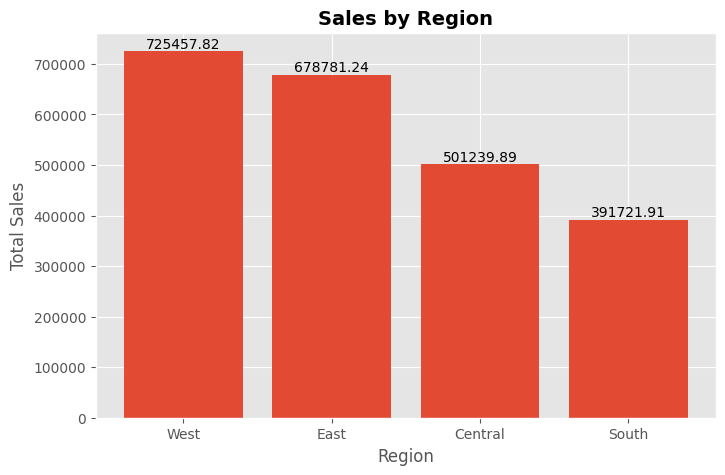

In [40]:
plt.figure(figsize=(8,5))

plt.bar(region_sales['region'], region_sales['sales'])

plt.title("Sales by Region", fontsize=14, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Total Sales")

for i, v in enumerate(region_sales['sales']):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.show()

Monthly Trend

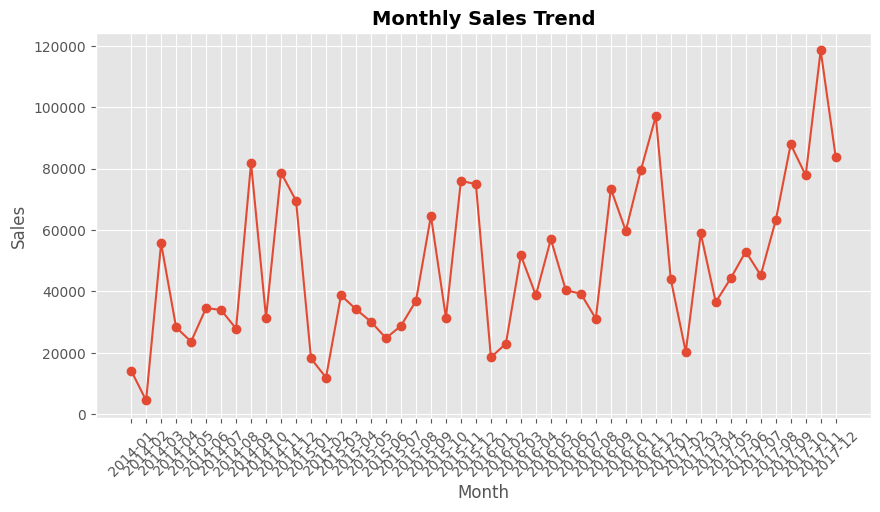

In [42]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['month'], monthly_sales['sales'], marker='o')

plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

Top Products

In [37]:
query = """
SELECT sub_category, SUM(sales) AS total_sales
FROM superstore
GROUP BY sub_category
ORDER BY total_sales DESC
LIMIT 5
"""

top_products = pd.read_sql(query, conn)
top_products

,sub_category,total_sales
0,Phones,330007.054
1,Chairs,328449.103
2,Storage,223843.608
3,Tables,206965.532
4,Binders,203412.733


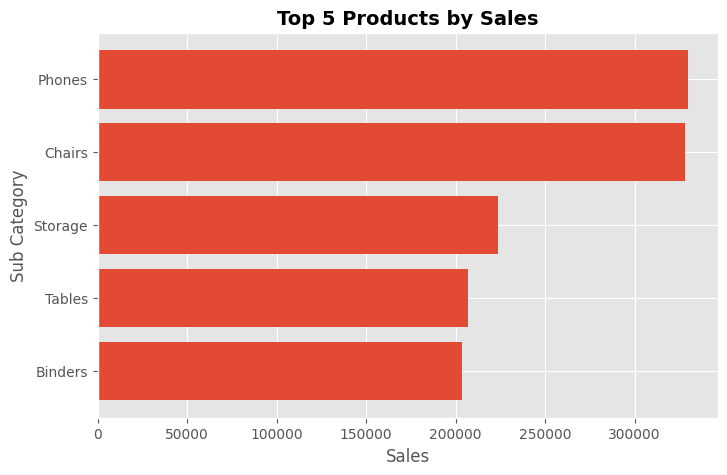

In [43]:
plt.figure(figsize=(8,5))

plt.barh(top_products['sub_category'], top_products['total_sales'])

plt.title("Top 5 Products by Sales", fontsize=14, fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Sub Category")

plt.gca().invert_yaxis()

plt.show()

Top 5 sub-categories with highest profit margin

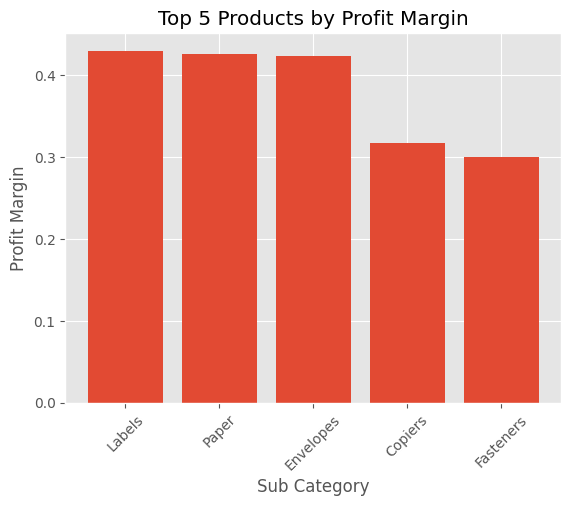

In [39]:
plt.figure()
plt.bar(profit_margin_analysis['sub_category'], profit_margin_analysis['avg_margin'])
plt.xticks(rotation=45)
plt.title("Top 5 Products by Profit Margin")
plt.xlabel("Sub Category")
plt.ylabel("Profit Margin")
plt.show()

Profit Margin

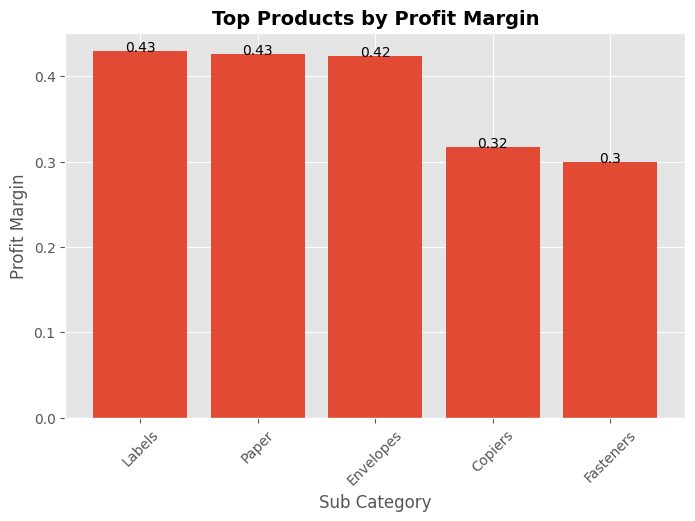

In [44]:
plt.figure(figsize=(8,5))

plt.bar(profit_margin_analysis['sub_category'], profit_margin_analysis['avg_margin'])

plt.title("Top Products by Profit Margin", fontsize=14, fontweight='bold')
plt.xlabel("Sub Category")
plt.ylabel("Profit Margin")

plt.xticks(rotation=45)

for i, v in enumerate(profit_margin_analysis['avg_margin']):
    plt.text(i, v, round(v, 2), ha='center')

plt.show()

Insights

1. Revenue and Profitability Performance: The analysis confirms a high-volume operation with total sales reaching $2,297,200.86. The cumulative profit stands at $286,397.02, reflecting a stable overall margin across the dataset's 9,994 transactions.
2. Operational Efficiency: Through the development of a custom profit_margin metric (Profit / Sales), the project establishes a framework for identifying which specific products or categories are driving value versus those that may be underperforming.
 1. Regional Performance
The West region contributes the highest share of total sales, indicating strong market presence and customer demand in that region. This suggests an opportunity to further invest in marketing and inventory expansion in high-performing regions.
2. Product-Level Revenue Drivers
Certain sub-categories such as Phones and Chairs are among the top revenue-generating products, highlighting their importance in driving overall sales. These categories can be prioritized for promotions and stock optimization.
3. Profitability Concerns
Some sub-categories, despite generating good sales, show low or negative profit margins, indicating pricing inefficiencies or high operational costs. This requires cost optimization or pricing strategy adjustments.
4. Seasonal Sales Trends
Sales show noticeable peaks during specific months (especially year-end periods), suggesting strong seasonal demand. Businesses can leverage this trend by planning targeted campaigns and inventory management during peak periods.
5. High Profit Margin Opportunities
Sub-categories with higher average profit margins present an opportunity to maximize profitability by focusing on upselling and increasing their sales share.
 6. Loss-Making Categories
A few product categories consistently contribute to losses, indicating the need for re-evaluation of product strategy, such as discontinuation, supplier negotiation, or cost reduction.